## 1. Setup & Data Load

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data (Excel file available in repo)
df = pd.read_excel('path to ML_Data_Synthetic.xlsx', sheet_name='Daily_Production_Energy')

print(df.shape)
df.head()

(520, 11)


,Date,Day_of_Week,Shift_Pattern,Precipitation_(mm),Avg_Temp_C,Shutdown_Week,Maintenance_Day,Planned_Lineoff,Lineoff,Total (KWh),Gentan-I (KWh/Veh)
0,2022-01-03,Monday,2-Shift,0.0,19.0,No,No,126,126,94585.18,750.68
1,2022-01-04,Tuesday,2-Shift,3.6,18.9,No,No,144,153,99890.42,652.88
2,2022-01-05,Wednesday,2-Shift,19.3,17.7,No,No,147,142,103097.48,726.04
3,2022-01-06,Thursday,2-Shift,7.9,17.4,No,No,143,150,96450.62,643.00
4,2022-01-07,Friday,2-Shift,3.2,16.7,No,No,124,130,96595.52,743.04


## 2. Data Cleaning — Fix Dates & Sort Chronologically

In [3]:
# Chronologically sort 
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# No duplicate date
print("Duplicate dates:", df['Date'].duplicated().sum())
print("Date range:", df['Date'].min(), "to", df['Date'].max())

Duplicate dates: 0
Date range: 2022-01-03 00:00:00 to 2023-12-29 00:00:00


## 3. Data Cleaning — Encode Binary Flags

In [4]:
# Convert Yes/No columns to binary
df['Shutdown_Week'] = (df['Shutdown_Week'] == 'Yes').astype(int)
df['Maintenance_Day'] = (df['Maintenance_Day'] == 'Yes').astype(int)

df[['Date', 'Shutdown_Week', 'Maintenance_Day']].head()

,Date,Shutdown_Week,Maintenance_Day
0,2022-01-03,0,0
1,2022-01-04,0,0
2,2022-01-05,0,0
3,2022-01-06,0,0
4,2022-01-07,0,0


## 4. Exploratory Analysis — Historical Trends

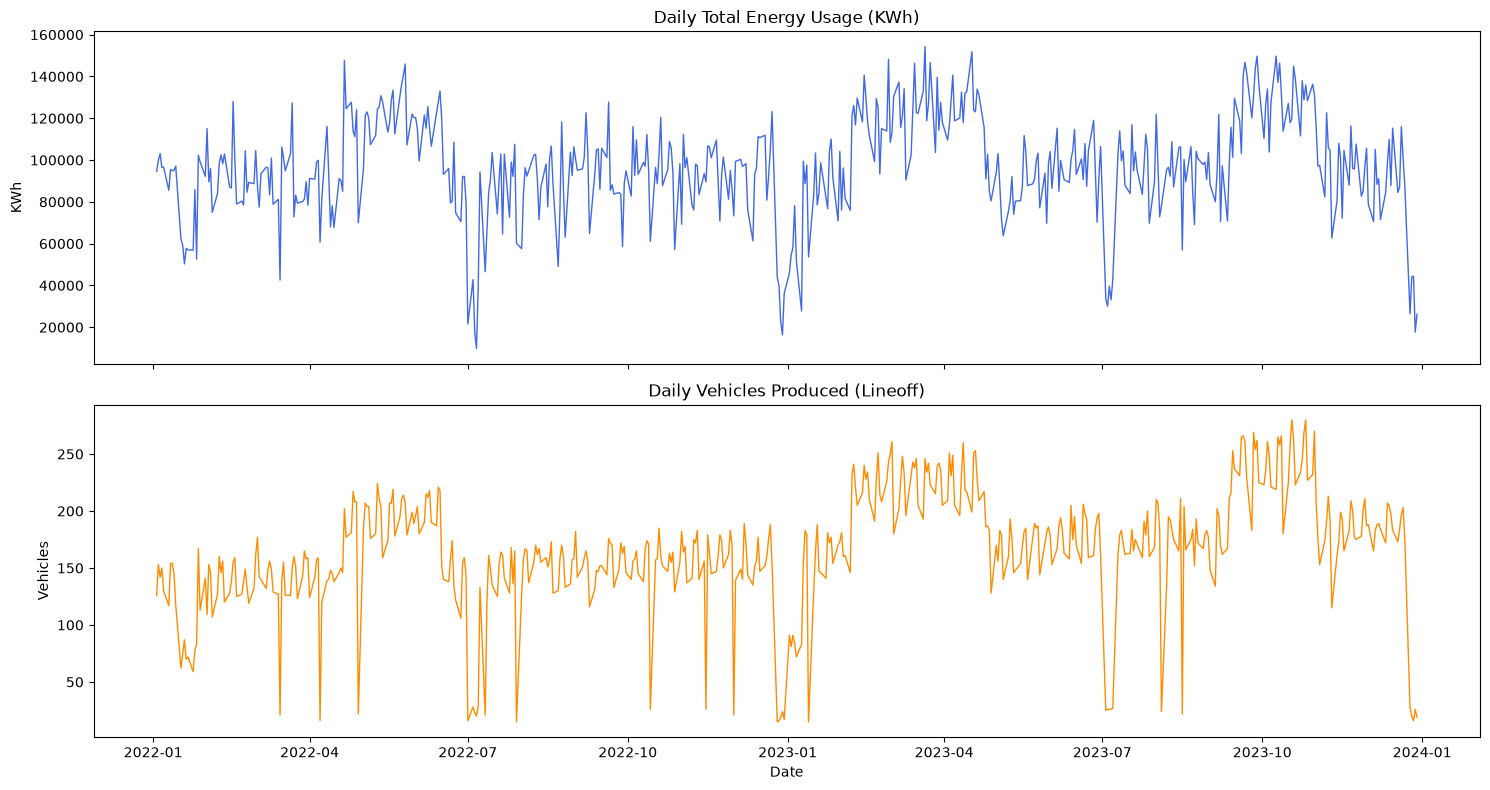

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

#Energy Usage plot
axes[0].plot(df['Date'], df['Total (KWh)'], color='royalblue', linewidth=1)
axes[0].set_title('Daily Total Energy Usage (KWh)')
axes[0].set_ylabel('KWh')

#Lineoff (No. of Vehicles Produced) plot 
axes[1].plot(df['Date'], df['Lineoff'], color='darkorange', linewidth=1)
axes[1].set_title('Daily Vehicles Produced (Lineoff)')
axes[1].set_ylabel('Vehicles')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

## 5. Exploratory Analysis — Feature Correlations

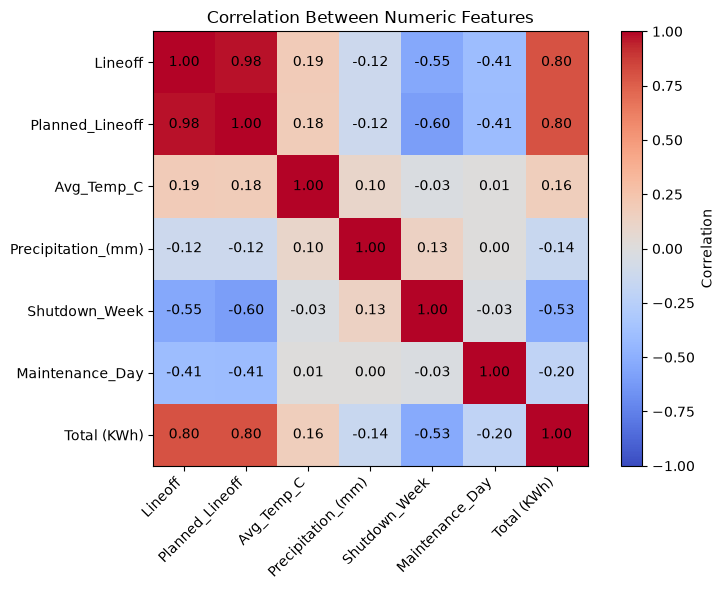

In [6]:
numeric_cols = ['Lineoff', 'Planned_Lineoff', 'Avg_Temp_C', 'Precipitation_(mm)',
                 'Shutdown_Week', 'Maintenance_Day', 'Total (KWh)']

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)

# Print the actual numbers on top of the squares
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.show()

## 6. Chronological Train/Test Split (80/20)

In [ ]:
# Chronological, NOT random — a random split would leak future dates into training, which is invalid for time series forecasting

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print(f"Train: {train['Date'].min().date()} to {train['Date'].max().date()} ({len(train)} rows)")
print(f"Test:  {test['Date'].min().date()} to {test['Date'].max().date()} ({len(test)} rows)")

Train: 2022-01-03 to 2023-08-07 (416 rows)
Test:  2023-08-08 to 2023-12-29 (104 rows)


## 7. Baseline Model — Lineoff Only

In [ ]:
# This is the floor every other model must beat to justify complexity

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X_train = train[['Lineoff']]
y_train = train['Total (KWh)']

X_test = test[['Lineoff']]
y_test = test['Total (KWh)']

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Baseline Model (Lineoff only)")
print(f"Slope (kWh per additional car): {baseline_model.coef_[0]:.2f}")
print(f"Intercept (baseline plant kWh): {baseline_model.intercept_:.2f}")
print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.2f} kWh")

Baseline Model (Lineoff only)
Slope (kWh per additional car): 382.03
Intercept (baseline plant kWh): 34664.76
R²: 0.681
MAE: 12347.28 kWh


## 8. Multi-Feature Model (Lineoff + Weather + Shift + Shutdown/Maintenance)

In [9]:
df = pd.get_dummies(df, columns=['Shift_Pattern'], drop_first=True)

# Re-slice train/test now that df has new columns
train = df.iloc[:split_index]
test = df.iloc[split_index:]

features = ['Lineoff', 'Avg_Temp_C', 'Precipitation_(mm)', 'Shutdown_Week', 'Maintenance_Day',
            'Shift_Pattern_2-Shift', 'Shift_Pattern_3-Shift']

X_train = train[features]
y_train = train['Total (KWh)']
X_test = test[features]
y_test = test['Total (KWh)']

multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

y_pred = multi_model.predict(X_test)

print("Multi-Feature Model")
print(f"R²: {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} kWh")
print()
for name, coef in zip(features, multi_model.coef_):
    print(f"{name}: {coef:.2f}" + " kWh per unit change")

Multi-Feature Model
R²: 0.769
MAE: 10527.89 kWh

Lineoff: 157.59 kWh per unit change
Avg_Temp_C: -188.80 kWh per unit change
Precipitation_(mm): -169.67 kWh per unit change
Shutdown_Week: -39302.38 kWh per unit change
Maintenance_Day: -9932.45 kWh per unit change
Shift_Pattern_2-Shift: 24956.95 kWh per unit change
Shift_Pattern_3-Shift: 45758.76 kWh per unit change


## 9. Efficiency Curve — Gentan-I vs. Daily Volume

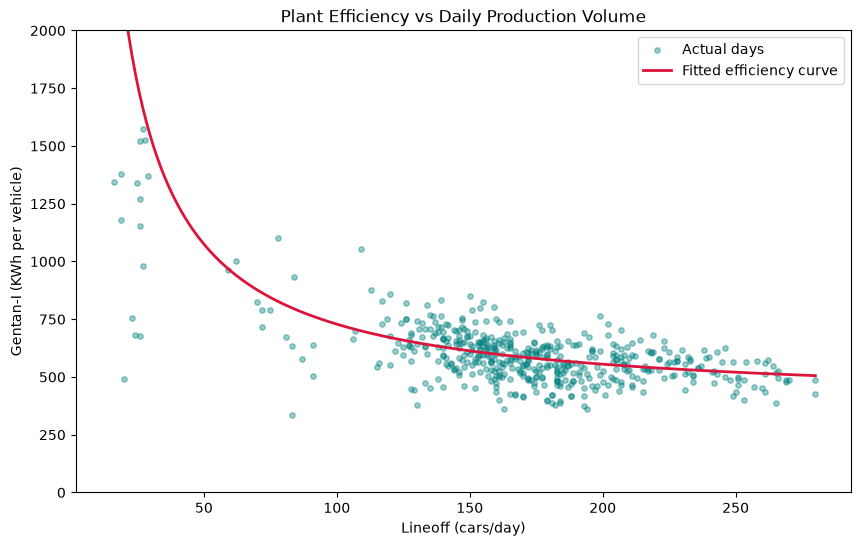

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Lineoff'], df['Gentan-I (KWh/Veh)'], alpha=0.4, s=15, color='teal', label='Actual days')

lineoff_range = np.linspace(df['Lineoff'].min(), df['Lineoff'].max(), 200)
predicted_total = baseline_model.intercept_ + baseline_model.coef_[0] * lineoff_range
predicted_gentani = predicted_total / lineoff_range

plt.plot(lineoff_range, predicted_gentani, color='crimson', linewidth=2, label='Fitted efficiency curve')
plt.xlabel('Lineoff (cars/day)')
plt.ylabel('Gentan-I (KWh per vehicle)')
plt.title('Plant Efficiency vs Daily Production Volume')
plt.ylim(0, 2000)
plt.legend()
plt.show()

## 10. Single-Day Prediction Function

In [11]:
def predict_daily_energy(lineoff, avg_temp_c, precipitation_mm,
                          shift_pattern='2-Shift', is_shutdown_week=False, is_maintenance_day=False):
    
    shift_2 = 1 if shift_pattern == '2-Shift' else 0
    shift_3 = 1 if shift_pattern == '3-Shift' else 0
    
    input_row = pd.DataFrame([{
        'Lineoff': lineoff,
        'Avg_Temp_C': avg_temp_c,
        'Precipitation_(mm)': precipitation_mm,
        'Shutdown_Week': int(is_shutdown_week),
        'Maintenance_Day': int(is_maintenance_day),
        'Shift_Pattern_2-Shift': shift_2,
        'Shift_Pattern_3-Shift': shift_3
    }])
    
    predicted_kwh = multi_model.predict(input_row)[0]
    return predicted_kwh

# Quick test - a normal 2-shift day, 200 cars, 28C, no rain
test_prediction = predict_daily_energy(lineoff=200, avg_temp_c=28, precipitation_mm=0)
print(f"Predicted energy: {test_prediction:.2f} kWh")

Predicted energy: 99542.54 kWh


## 11. Interactive Predictor (Widget)

In [ ]:
import ipywidgets as widgets
from IPython.display import display

def interactive_predict(lineoff, avg_temp_c, precipitation_mm, shift_pattern, is_shutdown_week, is_maintenance_day):
    result = predict_daily_energy(lineoff, avg_temp_c, precipitation_mm,
                                   shift_pattern, is_shutdown_week, is_maintenance_day)
    print(f"Predicted Total Energy: {result:,.2f} kWh")
    if lineoff > 0:
        print(f"Predicted Gentan-I:     {result / lineoff:,.2f} kWh/vehicle")

widgets.interact(
    interactive_predict,
    lineoff=widgets.IntSlider(min=0, max=300, step=5, value=200, description='Lineoff'),
    avg_temp_c=widgets.FloatSlider(min=15, max=35, step=0.5, value=28, description='Temp (°C)'),
    precipitation_mm=widgets.FloatSlider(min=0, max=90, step=1, value=0, description='Rain (mm)'),
    shift_pattern=widgets.Dropdown(options=['1-Shift', '2-Shift', '3-Shift'], value='2-Shift', description='Shift'),
    is_shutdown_week=widgets.Checkbox(value=False, description='Shutdown Week'),
    is_maintenance_day=widgets.Checkbox(value=False, description='Maintenance Day'),
)

interactive(children=(IntSlider(value=200, description='Lineoff', max=300, step=5), FloatSlider(value=28.0, de…

<function __main__.interactive_predict(lineoff, avg_temp_c, precipitation_mm, shift_pattern, is_shutdown_week, is_maintenance_day)>

## 12. Weekly Forecast Planner (Mon-Fri)

         day  lineoff  predicted_kwh  predicted_gentani
0     Monday      180       96579.58             536.55
1    Tuesday      195       98754.60             506.43
2  Wednesday       70       78018.96            1114.56
3   Thursday      105       84382.89             803.65
4     Friday      130       88133.78             677.95

Total projected energy for the week: 445,869.82 kWh


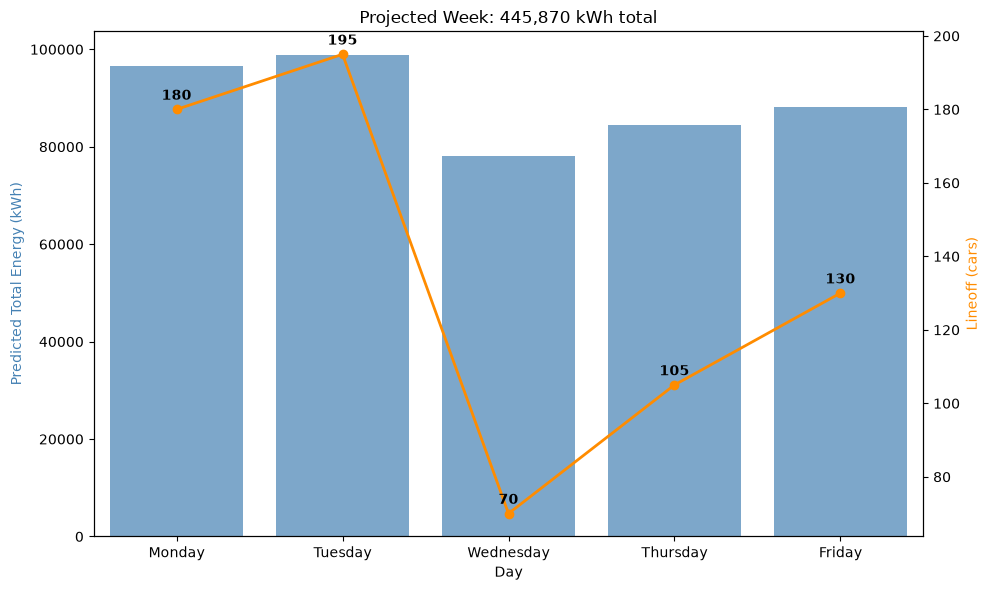

In [35]:
next_week_plan = [
    {'day': 'Monday',    'lineoff': 180, 'avg_temp_c': 27, 'precipitation_mm': 0, 'shift_pattern': '2-Shift'},
    {'day': 'Tuesday',   'lineoff': 195, 'avg_temp_c': 28, 'precipitation_mm': 0, 'shift_pattern': '2-Shift'},
    {'day': 'Wednesday', 'lineoff': 70, 'avg_temp_c': 29, 'precipitation_mm': 5, 'shift_pattern': '2-Shift'},
    {'day': 'Thursday',  'lineoff': 105, 'avg_temp_c': 29, 'precipitation_mm': 0, 'shift_pattern': '2-Shift'},
    {'day': 'Friday',    'lineoff': 130, 'avg_temp_c': 30, 'precipitation_mm': 0, 'shift_pattern': '2-Shift'},
]

results = []
for day_plan in next_week_plan:
    predicted_kwh = predict_daily_energy(
        lineoff=day_plan['lineoff'],
        avg_temp_c=day_plan['avg_temp_c'],
        precipitation_mm=day_plan['precipitation_mm'],
        shift_pattern=day_plan['shift_pattern']
    )
    results.append({'day': day_plan['day'], 'lineoff': day_plan['lineoff'], 'predicted_kwh': predicted_kwh})

forecast_df = pd.DataFrame(results)
forecast_df['predicted_gentani'] = forecast_df['predicted_kwh'] / forecast_df['lineoff']

print(forecast_df.round(2))
print(f"\nTotal projected energy for the week: {forecast_df['predicted_kwh'].sum():,.2f} kWh")

fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary axis (Bars)
ax1.bar( forecast_df['day'], forecast_df['predicted_kwh'],color='steelblue', alpha=0.7, label='Predicted kWh',)
ax1.set_ylabel('Predicted Total Energy (kWh)', color='steelblue')
ax1.set_xlabel('Day')

# Secondary axis (Line)
ax2 = ax1.twinx()
ax2.plot(forecast_df['day'], forecast_df['lineoff'], color='darkorange', marker='o', linewidth=2, label='Lineoff', zorder=3)
ax2.set_ylabel('Lineoff (cars)', color='darkorange')

# Add horizontal dotted lines from each point to the right y-axis & label values
x_max = len(forecast_df) - 0.5  # Edge of the right axis boundary

for idx, val in enumerate(forecast_df['lineoff']):

  # Direct data label next to each point
  ax2.annotate( f'{val}', (idx, val), textcoords='offset points', xytext=(0, 7), ha='center', color='black', fontweight='bold')

# Align axis limits so the lines reach cleanly to the edge
ax1.set_xlim(-0.5, x_max)

plt.title(f"Projected Week: {forecast_df['predicted_kwh'].sum():,.0f} kWh total")
fig.tight_layout()
plt.show()

## 13. Model Validation — Historical Fit with Regression Line

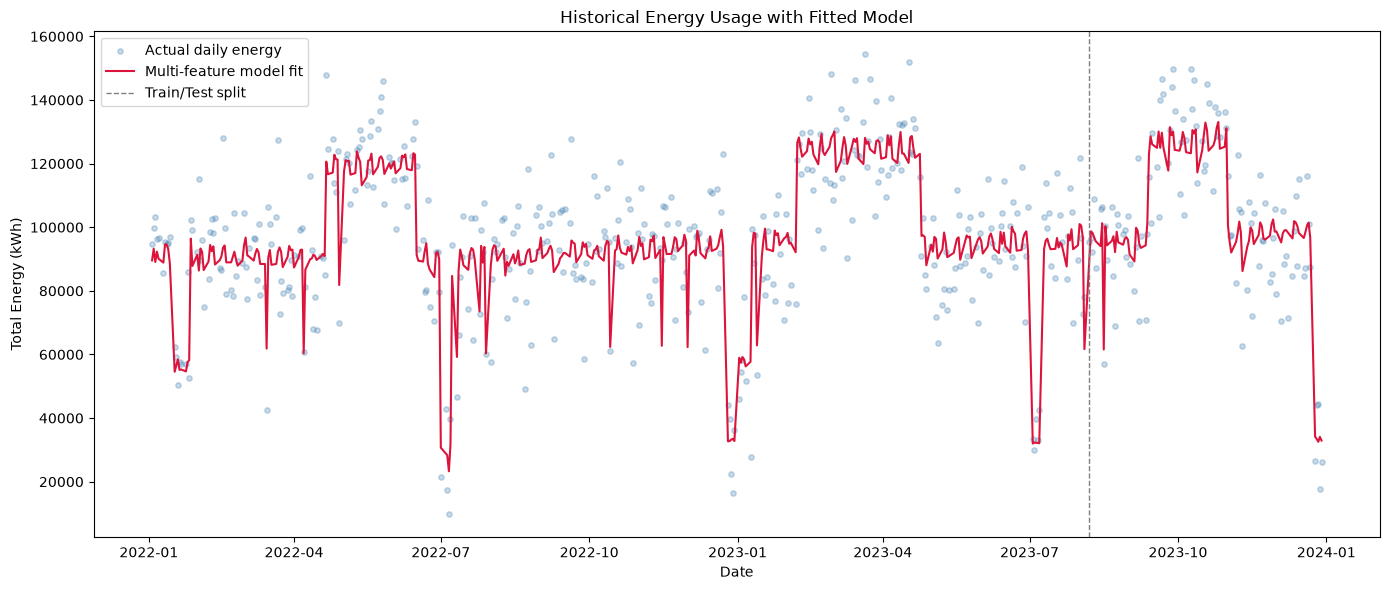

In [24]:
plt.figure(figsize=(14, 6))
plt.scatter(df['Date'], df['Total (KWh)'], alpha=0.3, s=15, color='steelblue', label='Actual daily energy')

df['multi_model_fitted'] = multi_model.predict(df[features])
plt.plot(df['Date'], df['multi_model_fitted'], color='crimson', linewidth=1.5, label='Multi-feature model fit')

plt.axvline(train['Date'].max(), color='gray', linestyle='--', linewidth=1, label='Train/Test split')
plt.xlabel('Date')
plt.ylabel('Total Energy (kWh)')
plt.title('Historical Energy Usage with Fitted Model')
plt.legend()
plt.tight_layout()
plt.show()

## 14. Model Validation — Actual vs. Predicted (Test Set)

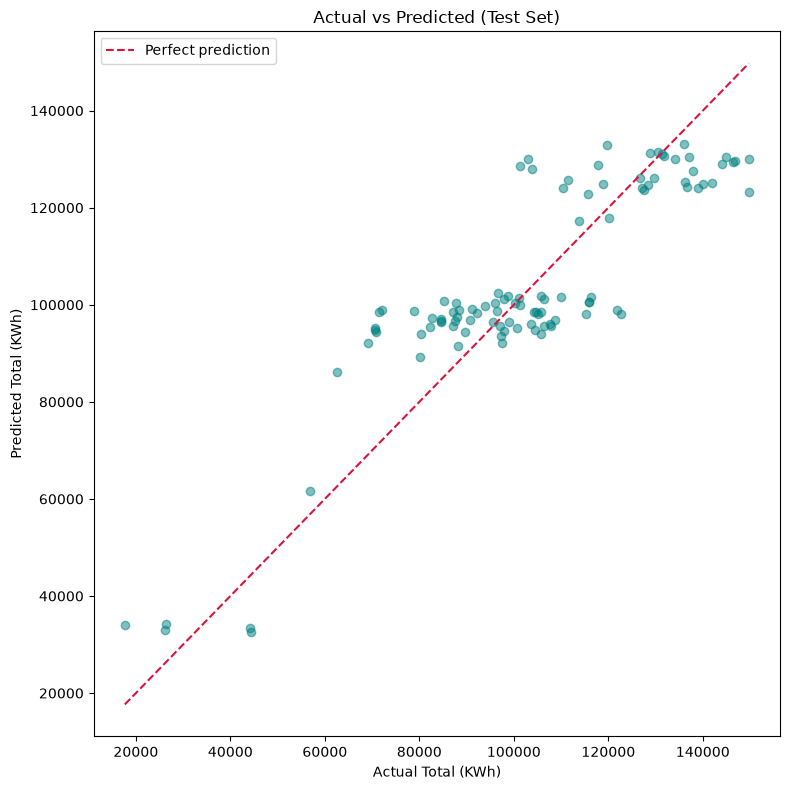

In [25]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color='crimson', linestyle='--', label='Perfect prediction')

plt.xlabel('Actual Total (KWh)')
plt.ylabel('Predicted Total (KWh)')
plt.title('Actual vs Predicted (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()